In [ ]:
#'block_size': 256,
#'n_embed': 384,
#'n_layers': 6,
#'n_heads': 6,

# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 128,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 2,
    "learning_rate": 3e-4,
    "max_steps": 500,
    #"dropout": 0.1,
    "layer_norm_enabled": True,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
#DATASET_TEXT = DATASET_TEXT[:1000]

Find tokens:

In [4]:
chars = sorted(list(set(DATASET_TEXT)))
chars

['\n',
 ' ',
 '!',
 '$',
 '&',
 "'",
 ',',
 '-',
 '.',
 '3',
 ':',
 ';',
 '?',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Create tokenizer:

In [5]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [6]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 0.4462,  0.7270,  0.0552,  ...,  0.3169, -0.5459,  1.1410],
         [ 0.4462,  0.7270,  0.0552,  ...,  0.3169, -0.5459,  1.1410],
         [ 0.4462,  0.7270,  0.0552,  ...,  0.3169, -0.5459,  1.1410],
         ...,
         [ 0.9789, -1.1752,  0.3047,  ...,  2.0024,  0.8543, -0.7329],
         [ 0.9789, -1.1752,  0.3047,  ...,  2.0024,  0.8543, -0.7329],
         [ 2.0269, -0.6152, -0.6694,  ...,  0.7480,  0.6268,  2.1212]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [7]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[ 1.0495,  0.3262, -0.9863,  ..., -0.0850, -0.0183,  1.6706],
         [-0.9382, -1.1218, -0.4573,  ...,  0.3757, -1.0802, -0.1434],
         [ 0.8364, -0.3086,  0.4318,  ...,  0.3038, -0.9966,  0.6465],
         ...,
         [ 1.0978, -1.6956, -1.6513,  ...,  1.8059,  1.7846, -1.5870],
         [-1.7529, -0.3191,  0.4295,  ...,  0.6331,  0.5497,  0.1395],
         [ 1.7836, -0.2038, -0.0546,  ...,  0.4242,  1.6576,  1.0089]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [8]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[ 1.4956,  1.0532, -0.9311,  ...,  0.2319, -0.5643,  2.8116],
         [-0.4920, -0.3948, -0.4020,  ...,  0.6926, -1.6261,  0.9977],
         [ 1.2826,  0.4185,  0.4871,  ...,  0.6207, -1.5425,  1.7875],
         ...,
         [ 2.0768, -2.8708, -1.3466,  ...,  3.8083,  2.6389, -2.3200],
         [-0.7740, -1.4944,  0.7342,  ...,  2.6355,  1.4040, -0.5934],
         [ 3.8105, -0.8190, -0.7240,  ...,  1.1721,  2.2844,  3.1301]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [9]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[42,  1, 40,  ..., 46,  6,  1],
         [ 1, 47, 52,  ..., 39, 63,  1],
         [41, 46, 39,  ..., 47, 57,  1],
         ...,
         [63, 57, 43,  ..., 58, 46, 43],
         [47, 52,  1,  ..., 57, 58, 43],
         [46, 47, 57,  ...,  0,  0, 32]]),
 torch.Size([10, 128]),
 tensor([[ 1, 40, 43,  ...,  6,  1, 51],
         [47, 52, 58,  ..., 63,  1, 46],
         [46, 39, 57,  ..., 57,  1, 46],
         ...,
         [57, 43, 50,  ..., 46, 43,  1],
         [52,  1, 46,  ..., 58, 43, 56],
         [47, 57,  1,  ...,  0, 32, 30]]))

Test decoding batch:

In [10]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: d be thank'd, there's no need of me,
And much I need to help you, if need were;
The royal tree hath left us royal fruit,
Which, 
y 0:  be thank'd, there's no need of me,
And much I need to help you, if need were;
The royal tree hath left us royal fruit,
Which, m

x 1:  into his ears?
Then all too late comes counsel to be heard,
Where will doth mutiny with wit's regard.
Direct not him whose way 
y 1: into his ears?
Then all too late comes counsel to be heard,
Where will doth mutiny with wit's regard.
Direct not him whose way h

x 2: chasing.

VIRGILIA:
The gods grant them true!

VOLUMNIA:
True! pow, wow.

MENENIUS:
True! I'll be sworn they are true.
Where is 
y 2: hasing.

VIRGILIA:
The gods grant them true!

VOLUMNIA:
True! pow, wow.

MENENIUS:
True! I'll be sworn they are true.
Where is h

x 3:  seem to wear one heart,
Whose house, whose bed, whose meal, and exercise,
Are still together, who twin, as 'twere, in love
Unse
y 3: seem to wear one heart,
Whose house, whose bed, whose 

In [11]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([128, 128, 64]),
 tensor([ 0.9523,  0.3340,  0.0381,  1.0626,  0.8347,  0.1570, -0.4903,  0.2524,
          0.8246,  0.1634,  0.5090, -0.2877,  1.3533, -0.9793,  0.7411, -2.2710,
          0.1794,  2.1145, -0.2831, -1.2830, -0.2531,  1.1326, -1.2497, -1.4182,
         -1.1002, -1.7597,  0.9773, -0.8310,  1.5372,  2.2940, -1.0669, -1.4465,
         -2.5099,  0.4895,  0.3570, -0.3125,  0.3793,  0.1504, -0.0626, -2.5867,
          0.7148,  0.4791, -0.6834,  0.0074, -1.0796,  0.7950, -0.5323,  0.5676,
          0.1100, -0.9685,  1.9365, -1.8256, -0.9148,  0.0687,  0.2796,  0.0591,
         -2.8871,  0.0292, -1.7443,  1.1998, -2.2685, -0.3780,  0.2107,  4.1288],
        grad_fn=<SelectBackward0>))

In [12]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [13]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]))

In [14]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([128, 64, 128])

In [15]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([128, 128, 128]),
 tensor([   -9.3463,  1333.6506,   641.2515, -1638.4780,  1197.2096,  1202.4515,
         -1083.5673,  1402.0396,   452.7427,  1306.3242,  -736.9328,   995.5346,
         -1606.9146, -1047.3986,  1457.8430,  1036.1239, -1401.8905,  2951.7393,
           919.6952, -1088.4792,  2562.5735, -1474.5850,  -152.1063, -1076.0148,
          1733.7340,  -211.3926,   694.1998,   182.0585,  1979.3844,  -192.9225,
            81.7547,  1057.1195, -1458.0906,   -44.0400,  -859.1626,  1038.9850,
           380.2409,  1799.8387,  -446.8704,  1731.6172,  1893.1824,   186.2039,
            44.4451,  2248.7434,   750.8553,   -16.9970,   125.9627,   171.2192,
          -592.5280, -1844.2467,  -497.2262,  -956.3906,  -349.7292,   378.0034,
            84.4436,   110.3946,   155.7124,  -341.1139,  1501.9983,  -478.1784,
         -1946.7285,    71.8482,  -490.3784,   401.0967,  -903.6271,  -312.8819,
          2981.9473,   280.9577,  -682.9363,  1145.6239, -1234.2308,  -564.5822

In [16]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([128, 128, 128]),
 tensor([  -1.1683,  166.7063,   80.1564, -204.8098,  149.6512,  150.3064,
         -135.4459,  175.2549,   56.5928,  163.2905,  -92.1166,  124.4418,
         -200.8643, -130.9248,  182.2304,  129.5155, -175.2363,  368.9674,
          114.9619, -136.0599,  320.3217, -184.3231,  -19.0133, -134.5018,
          216.7168,  -26.4241,   86.7750,   22.7573,  247.4230,  -24.1153,
           10.2193,  132.1399, -182.2613,   -5.5050, -107.3953,  129.8731,
           47.5301,  224.9798,  -55.8588,  216.4521,  236.6478,   23.2755,
            5.5556,  281.0929,   93.8569,   -2.1246,   15.7453,   21.4024,
          -74.0660, -230.5308,  -62.1533, -119.5488,  -43.7161,   47.2504,
           10.5554,   13.7993,   19.4641,  -42.6392,  187.7498,  -59.7723,
         -243.3411,    8.9810,  -61.2973,   50.1371, -112.9534,  -39.1102,
          372.7434,   35.1197,  -85.3670,  143.2030, -154.2789,  -70.5728,
          -87.3501, -184.9697,   65.7712,   45.5805,  117.2626, -163.2

In [17]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [18]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [19]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([128, 128, 128]),
 tensor([[  -1.1683,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ -59.2563,  120.0577,      -inf,  ...,      -inf,      -inf,
               -inf],
         [  75.7903,  -71.1509,  -51.0299,  ...,      -inf,      -inf,
               -inf],
         ...,
         [  25.5090,  -29.3483,  -61.9396,  ...,   35.0869,      -inf,
               -inf],
         [ 188.4916, -111.5903,  184.7199,  ..., -181.9910,   44.3286,
               -inf],
         [ -13.5810, -154.1929,  120.8038,  ...,  -11.6476,   49.0625,
            77.5080]], grad_fn=<SelectBackward0>))

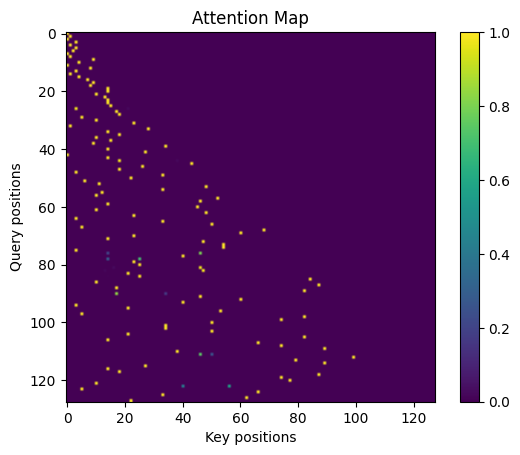

In [20]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [21]:
output = attention @ V
output.shape

torch.Size([128, 128, 64])

In [22]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([128, 128, 32]),
 tensor([[[-0.2312, -0.1564, -1.0772,  ..., -3.1732,  0.3575, -3.1627],
          [ 0.1648, -1.0684, -1.0442,  ..., -2.3667,  0.4323, -0.7266],
          [-0.2312, -0.1564, -1.0772,  ..., -3.1732,  0.3575, -3.1627],
          ...,
          [-0.0125, -1.5030, -0.0179,  ..., -2.3907, -0.9049, -0.1056],
          [-2.6473, -0.7799,  0.2304,  ...,  1.7503, -2.3440, -0.4519],
          [-1.5267, -0.4249, -0.2905,  ..., -0.0780, -0.3772,  1.1200]],
 
         [[ 2.7995, -1.4822,  0.9548,  ..., -1.8936, -0.2250, -0.2508],
          [-1.3219,  0.1138, -0.2330,  ..., -1.3149, -0.2587, -2.4914],
          [ 1.0134, -1.2684,  1.4429,  ..., -3.2366,  1.8742,  0.7604],
          ...,
          [-0.5927,  0.2897,  0.9398,  ..., -2.7685,  2.3892, -0.2802],
          [-2.0135,  0.9941,  1.4550,  ..., -1.2951, -3.9447, -2.0421],
          [-0.5037,  2.9720,  2.4627,  ...,  0.7962, -0.6997,  2.0595]],
 
         [[ 1.3019,  1.6433, -1.6663,  ..., -0.6570, -1.1549, -2.9210],

In [23]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        self.W_q = nn.Linear(embed_size, head_size)
        self.W_k = nn.Linear(embed_size, head_size)
        self.W_v = nn.Linear(embed_size, head_size)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[ 1.2194e+00, -2.4103e-02,  3.1518e-01],
          [ 5.3299e-01, -1.5988e-01,  3.0393e-01],
          [ 1.2816e-01, -3.3403e-01,  2.9630e-01],
          [ 6.3136e-01, -1.0525e-01,  5.2732e-01],
          [ 1.1032e-01, -1.8369e-01,  2.3875e-01],
          [ 2.4368e-01,  4.4138e-02,  3.5482e-01],
          [ 2.6441e-02, -2.1990e-02,  2.7431e-01],
          [-8.0905e-02, -1.0741e-01,  2.7104e-01],
          [-6.6769e-03, -1.0402e-01,  3.5690e-01],
          [-1.9035e-01, -1.7058e-01,  2.1280e-01],
          [-1.7113e-01, -1.0800e-01,  2.3012e-01],
          [-2.3484e-01, -9.3357e-02,  1.1663e-01],
          [-1.8770e-01, -9.1417e-02,  1.3878e-01],
          [-1.5941e-02, -2.0467e-02,  2.1718e-01],
          [-2.0414e-01, -8.1082e-02,  1.1558e-01],
          [-1.2427e-01, -4.9125e-02,  1.4819e-01],
          [ 3.5153e-02,  2.6281e-02,  2.1987e-01],
          [-1.5489e-01, -8.9689e-02,  1.5393e-01],
          [-3.2081e-02, -3.2508e-02,  1.1864e-01],
     

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.4079, -0.0705, -0.4857,  ...,  0.6162,  0.1120,  0.5817],
          [-0.1665,  0.2091, -0.2343,  ...,  0.3482,  0.2562,  0.2047],
          [-0.0319,  0.0617, -0.6286,  ...,  0.5291, -0.0242,  0.1651],
          ...,
          [-0.0630,  0.1513,  0.0302,  ...,  0.1222,  0.0033, -0.0038],
          [-0.0359,  0.1751, -0.0454,  ...,  0.0805,  0.0182, -0.0595],
          [-0.0829,  0.1317, -0.0078,  ...,  0.1008,  0.0072,  0.0338]]],
        grad_fn=<ViewBackward0>))

In [25]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.0845,  0.0209,  0.0631,  ..., -0.0603, -0.0287, -0.0030],
          [-0.1364,  0.0437,  0.0842,  ..., -0.0669, -0.0548, -0.0041],
          [-0.1184,  0.0267,  0.0904,  ..., -0.0590, -0.0541, -0.0008],
          ...,
          [-0.0784, -0.0052,  0.0462,  ..., -0.0552, -0.0393, -0.0381],
          [-0.0777, -0.0019,  0.0464,  ..., -0.0514, -0.0390, -0.0398],
          [-0.0803, -0.0052,  0.0488,  ..., -0.0538, -0.0393, -0.0360]]],
        grad_fn=<ViewBackward0>))

In [26]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = MultiHeadAttention()
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.1117,  0.6892, -0.2357,  ..., -0.4335,  0.3713,  1.4684],
          [ 0.0937,  1.4992, -0.0639,  ..., -0.8518, -0.1926,  0.1452],
          [ 0.9126, -1.6787,  0.3740,  ...,  1.7031,  1.2693, -0.5470],
          ...,
          [-0.0882, -1.4929, -0.3259,  ..., -0.3278,  1.6367,  1.2073],
          [ 1.5358, -0.9210,  0.2342,  ...,  0.0311,  0.6040,  1.1408],
          [-0.3910, -0.2779, -0.4876,  ..., -0.9347,  1.3157,  0.1517]]],
        grad_fn=<AddBackward0>))

In [27]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 46, 43, 50,
         50, 53]])

In [28]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 65]),
 tensor([-0.5676, -0.0525,  0.8238,  1.0233, -0.0417,  0.1123, -0.9920, -0.3614,
          0.6997, -0.6798,  0.2257,  0.3336, -0.2892, -0.7147, -0.2824, -0.7166,
          0.4099, -0.1773, -1.1455, -0.0849, -0.0911,  0.3660,  0.6189,  0.1724,
          0.1056,  1.0994,  0.6861, -0.9098,  0.1271,  0.1973, -0.1729, -0.8483,
         -0.0201, -0.9941,  0.0977,  0.1330, -0.3540, -0.2829,  1.0952,  0.9590,
          0.6073,  0.2856, -0.5778,  0.6968, -1.6421, -0.4628,  0.0278,  0.5784,
         -0.0046,  0.0898,  0.5560,  0.6933, -0.4016,  0.8205, -0.3314, -0.2796,
         -0.9943,  1.1120, -0.3861,  0.4366,  1.1891,  0.7907, -0.3130, -1.0285,
         -0.3672], grad_fn=<SelectBackward0>))

In [29]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:First Citi
y:irst Citiz


In [30]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:I had as
l
y: had as
li
---
x:
Wherein t
y:Wherein th
---
x: your fath
y:your fathe
---
x:rd honour 
y:d honour f
---
x:hould,
On 
y:ould,
On s
---
x:ast, west,
y:st, west, 
---
x:years hims
y:ears himse
---
x::
A deadly
y:
A deadly 
---
x: maid,
It 
y:maid,
It w
---
x:? and they
y: and they 
---


In [31]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(65, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-19): 20 x Block(
      (head): MultiHeadAttention(
        (heads): ModuleList(
          (0-1): 2 x AttentionHead(
            (W_q): Linear(in_features=64, out_features=32, bias=True)
            (W_k): Linear(in_features=64, out_features=32, bias=True)
            (W_v): Linear(in_features=64, out_features=32, bias=True)
          )
        )
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=65, bias=True)
  (ln_final): LayerNorm

In [32]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

In [33]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 1
losses = []
grad_norms = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        grad_norm = get_grad_norm(model)
        grad_norms.append(grad_norm)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.4f}")

Epoch 1/1:  40%|████      | 3525/8713 [24:13<35:39,  2.43it/s, grad_norm=1.1802, loss=1.4176]  


KeyboardInterrupt: 

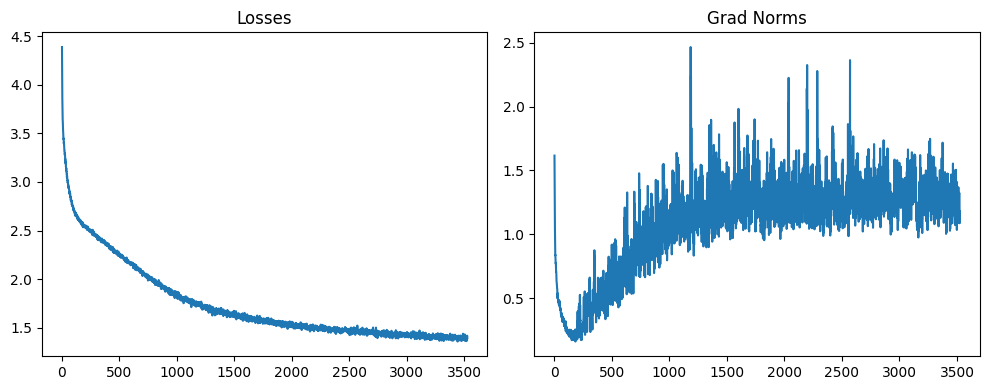

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [35]:
model.eval()
print(model.generate("We are accounted poor citizens, the patricians good.", max_len=200))



CLARENCE:
She is those burbward own.

Clown:
This is young princes. This

First a long willow is thy fatul on therefore.

CURTES:
Well will prince, lord, not fleeting murder in.

QUEEN ELIZABETH:
Bu


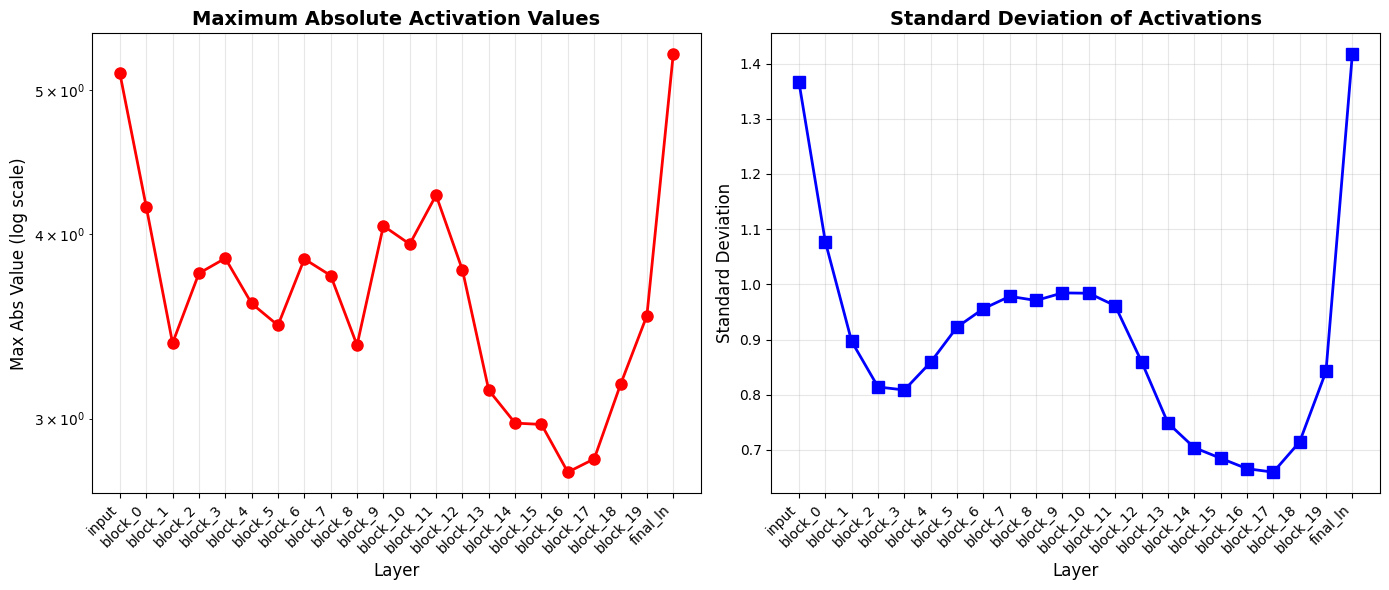


ACTIVATION STATISTICS
Layer                   Mean          Std      Max Abs
----------------------------------------------------------------------
input                -0.0345       1.3661       5.1332
block_0              -0.0766       1.0772       4.1717
block_1              -0.0583       0.8966       3.3739
block_2              -0.0872       0.8141       3.7608
block_3              -0.1342       0.8086       3.8498
block_4              -0.1227       0.8590       3.5884
block_5              -0.1235       0.9226       3.4686
block_6              -0.0727       0.9559       3.8460
block_7              -0.1434       0.9782       3.7479
block_8              -0.1768       0.9708       3.3630
block_9              -0.2380       0.9845       4.0491
block_10             -0.2474       0.9839       3.9357
block_11             -0.2774       0.9613       4.2471
block_12             -0.2680       0.8601       3.7807
block_13             -0.2585       0.7489       3.1352
block_14             -0.26

In [36]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")